# **Лабораторная работа №1 «Анализ и прогнозирование временных рядов на примере розничных продаж»**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from scipy.fft import fft, fftfreq
import pywt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import shapiro, jarque_bera
import warnings

In [ ]:
df = pd.read_csv('retail_sales_mock_data.csv')

df

,Date,SalesAmount,Promotion,HolidayMonth
0,2020-01-01,12248,0,0
1,2020-02-01,13011,0,0
2,2020-03-01,12722,0,0
3,2020-04-01,14030,1,0
4,2020-05-01,7783,0,0
5,2020-06-01,9131,1,0
6,2020-07-01,9089,0,0
7,2020-08-01,10300,0,0
8,2020-09-01,10464,0,0
9,2020-10-01,13786,1,0


# Разведочный анализ данных (EDA)

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df = df.sort_index()
df = df.asfreq('MS')

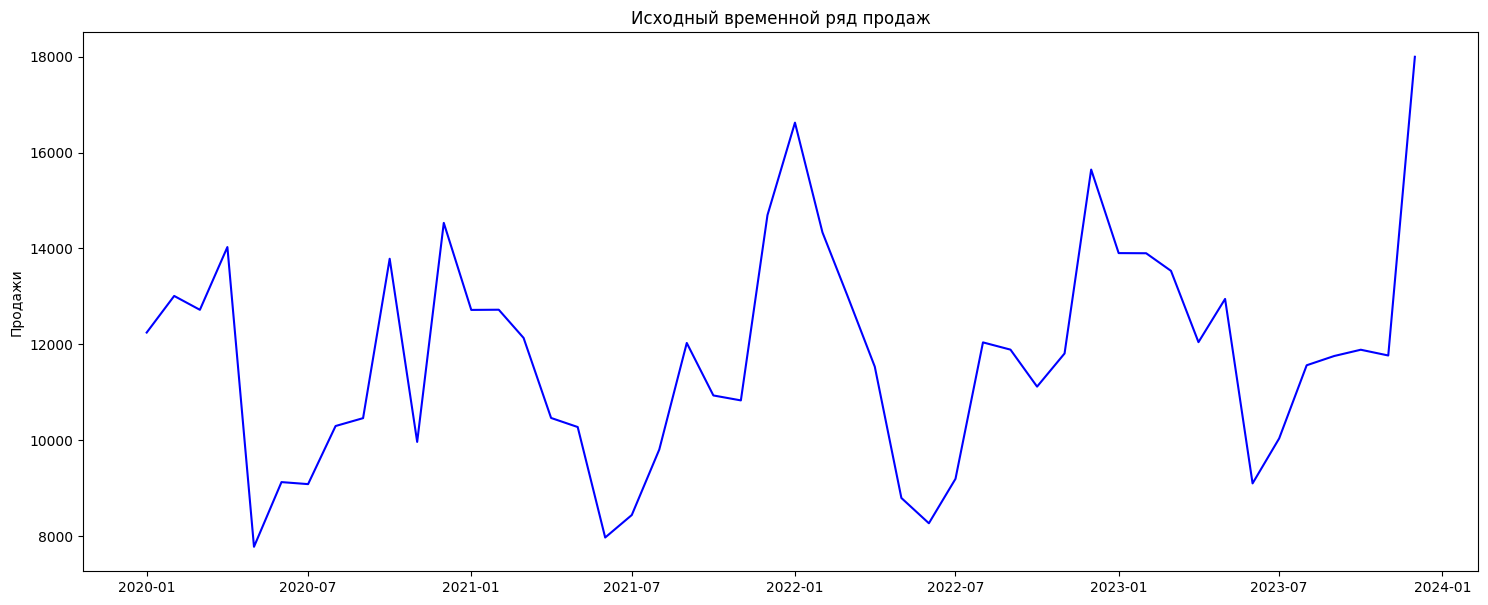

In [ ]:
# Визуализация ряда
fig, axes = plt.subplots(1, 1, figsize=(18, 7))
axes.plot(df.index, df['SalesAmount'], color='blue')
axes.set_title('Исходный временной ряд продаж')
axes.set_ylabel('Продажи')

plt.show()

На графике видна сезонность и тренд

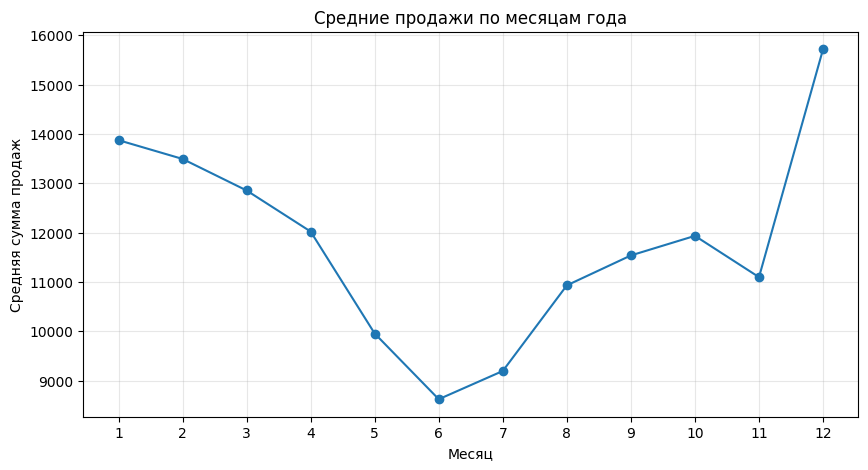

In [ ]:
df['month'] = df.index.month

seasonal_profile = df.groupby('month')['SalesAmount'].mean()

plt.figure(figsize=(10, 5))
plt.plot(seasonal_profile.index, seasonal_profile.values, marker='o')
plt.title('Средние продажи по месяцам года')
plt.xlabel('Месяц')
plt.ylabel('Средняя сумма продаж')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 13))
plt.show()

df.drop(columns=['month'], inplace=True)

# Декомпозиция временного ряда

## Аддитивная

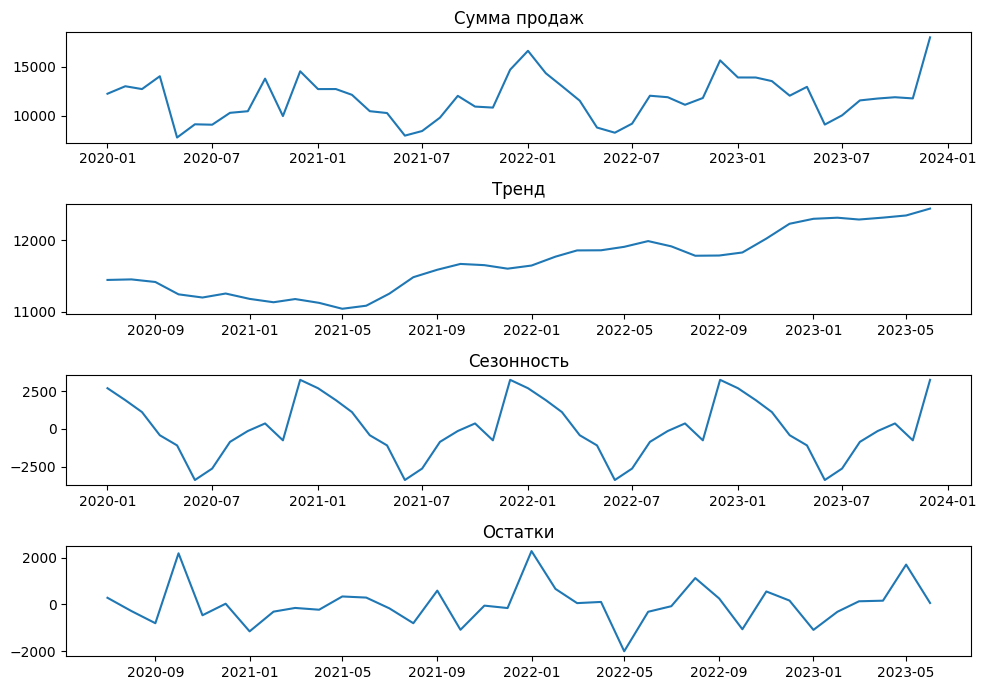

In [ ]:
seasonal_period = 12  # Годовая сезонность для месячных данных

decomp_add = seasonal_decompose(df['SalesAmount'], model='additive', period=seasonal_period)

fig, axes = plt.subplots(4, 1, figsize=(10, 7))
axes[0].plot(decomp_add.observed); axes[0].set_title('Сумма продаж')
axes[1].plot(decomp_add.trend); axes[1].set_title('Тренд')
axes[2].plot(decomp_add.seasonal); axes[2].set_title('Сезонность')
axes[3].plot(decomp_add.resid); axes[3].set_title('Остатки')

plt.tight_layout()
plt.show()

Вывод: тренд сначала немного падал, затем давнольно сильно пошёл вверх. Имеется ярко выраженая сезонность. Остатки являются случайными отклонениями

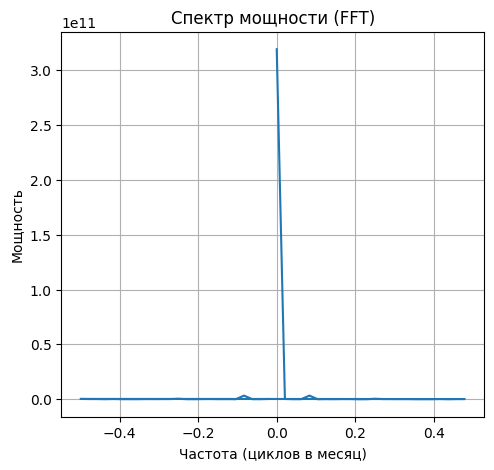

In [ ]:
# Спектральный анализ (FFT)
fft_vals = np.fft.fft(df['SalesAmount'].values)
fft_freq = np.fft.fftfreq(len(df), d=1)
power_spectrum = np.abs(fft_vals)**2

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fft_freq, power_spectrum)
plt.title('Спектр мощности (FFT)')
plt.xlabel('Частота (циклов в месяц)')
plt.ylabel('Мощность')
plt.grid()

plt.show()

Из спектрального анализа видно, что в ряду есть частотные компоненты, следовательно в данных сувществует периодичность

## Вейвлет-анализ

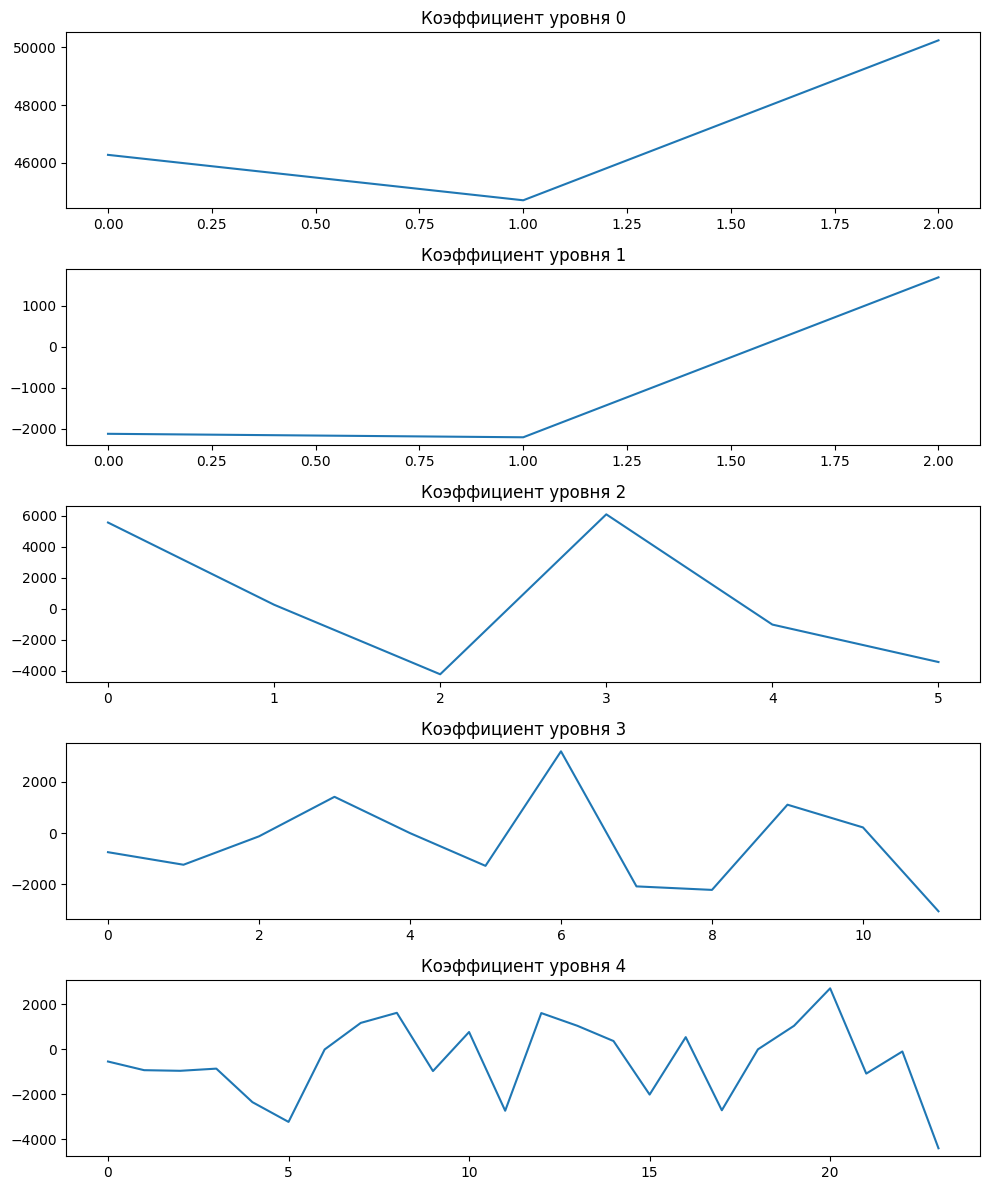

In [ ]:
coeffs = pywt.wavedec(df['SalesAmount'], 'db1', level=4)

fig, axes = plt.subplots(5, 1, figsize=(10, 12))
for i, coeff in enumerate(coeffs):
    axes[i].plot(coeff)
    axes[i].set_title(f'Коэффициент уровня {i}')
plt.tight_layout()
plt.show()

Вейвлет-анализ позволяет выделить различные уровни частотных компонент. Каждый уровень представляет собой определенный аспект колебаний временного ряда. Этот метод позволяет глубже понять сложные сезонные и трендовые компоненты, которые трудно выявить другими методами.

Благодаря способности выделять частотные составляющие по уровням, вейвлет-анализ служит мощным инструментом декомпозиции временных рядов, который позволяет выявить и интерпретировать сложные сезонные и трендовые компоненты

Вывод:

Классическая аддитивная декомпозиция:

Аддитивная декомпозиция наглядна и проста, успешно выделяя тренд и сезонность в регулярных рядах, но неэффективена для сложных временных рядов с переменной сезонностью или мультипликативным характером колебаний


Спектральный анализ (FFT):
Спектральный анализ уверенно доминирует в задаче поиска цикличности, однако требует фиксированной частотной структуры и теряет точность при наличии тренда.

Вейвлет-анализ:
Вейвлет-анализ позволил выделить высокочастотные и низкочастотные компоненты.Платой за эту за это становятся вычислительная сложность и более высокая планка интерпретации.

# Построение прогнозных моделей

## Модель ARIMA

In [ ]:
# Разделение на train/test (80/20)
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

model_arima = ARIMA(train['SalesAmount'], order=(10, 1, 4))
fitted_arima = model_arima.fit()
print(fitted_arima.summary())

forecast_arima = fitted_arima.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:            SalesAmount   No. Observations:                   38
Model:                ARIMA(10, 1, 4)   Log Likelihood                -352.545
Date:                Fri, 24 Apr 2026   AIC                            735.090
Time:                        00:02:17   BIC                            759.253
Sample:                    01-01-2020   HQIC                           743.608
                         - 02-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7345      0.108     -6.784      0.000      -0.947      -0.522
ar.L2         -0.6194      0.157     -3.954      0.000      -0.926      -0.312
ar.L3         -0.6664      0.153     -4.353      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Модель SARIMAX

In [ ]:
model_sarima = SARIMAX(train['SalesAmount'],
                       order=(2, 1, 2),
                       seasonal_order=(2, 1, 2, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
fitted_sarima = model_sarima.fit(disp=False)
print(fitted_sarima.summary())

forecast_sarima = fitted_sarima.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tools/eval_measures.py:414: RuntimeWarning: invalid value encountered in log
  return -2.0 * llf + np.log(nobs) * df_modelwc
/usr/local/lib/python3.12/dist-packages/statsmodels/tools/eval_measures.py:439: RuntimeWarning: invalid value encountered in log
  return -2.0 * llf + 2 * np.log(np.log(nobs)) * df_modelwc
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:3016: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:3016: RuntimeWarning: invalid value encountered in divide
  return self.params / self.bse
/usr

                                     SARIMAX Results                                      
Dep. Variable:                        SalesAmount   No. Observations:                   38
Model:             SARIMAX(2, 1, 2)x(2, 1, 2, 12)   Log Likelihood                   0.000
Date:                            Fri, 24 Apr 2026   AIC                             18.000
Time:                                    00:02:17   BIC                                nan
Sample:                                01-01-2020   HQIC                               nan
                                     - 02-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0026         -0        inf      0.000      -1.003      -1.003
ar.L2          0.0451         -0   

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


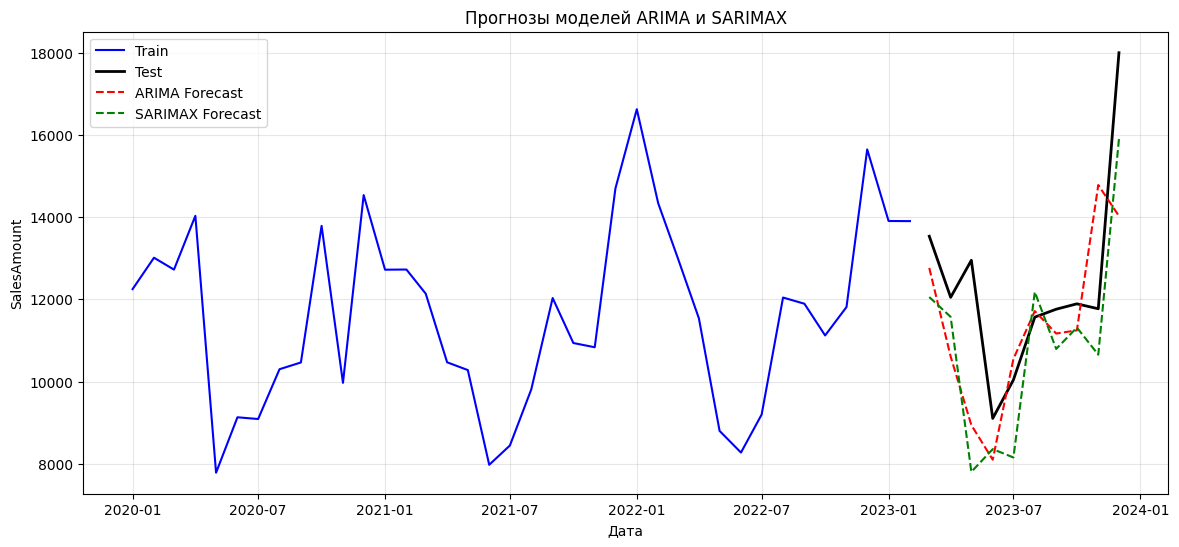

In [ ]:
# Визуализация прогнозов
plt.figure(figsize=(14, 6))
plt.plot(train.index, train['SalesAmount'], label='Train', color='blue')
plt.plot(test.index, test['SalesAmount'], label='Test', color='black', linewidth=2)
plt.plot(test.index, forecast_arima, label='ARIMA Forecast', color='red', linestyle='--')
plt.plot(test.index, forecast_sarima, label='SARIMAX Forecast', color='green', linestyle='--')
plt.title('Прогнозы моделей ARIMA и SARIMAX')
plt.xlabel('Дата')
plt.ylabel('SalesAmount')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

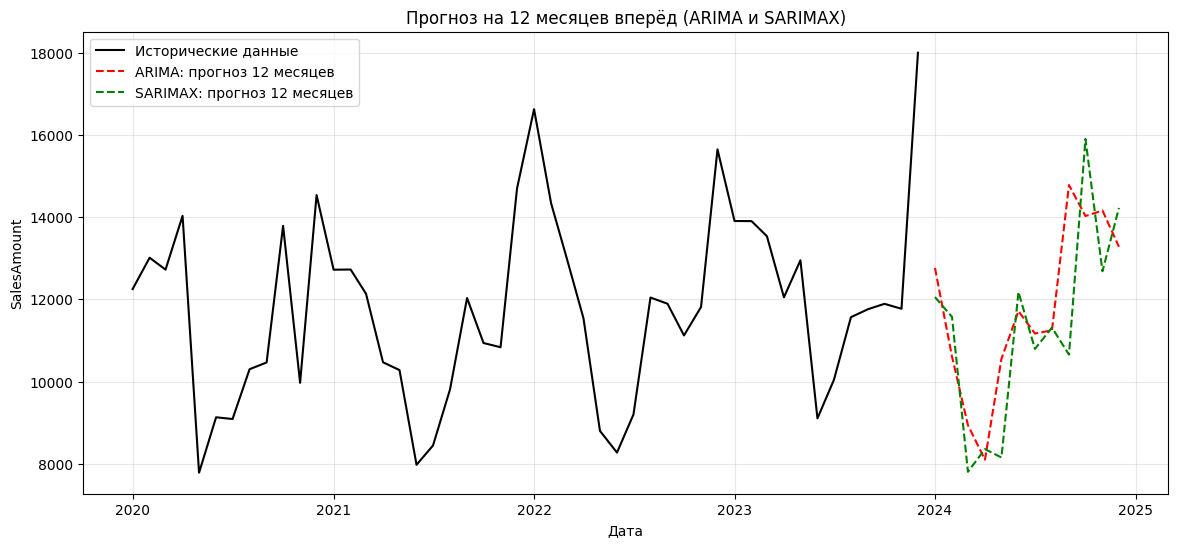

In [ ]:
# Прогноз на 12 месяцев вперёд (за пределами выборки)
future_steps = 12

future_forecast_arima = fitted_arima.forecast(steps=future_steps)
future_forecast_sarima = fitted_sarima.forecast(steps=future_steps)

last_date = df.index.max()
future_index = pd.date_range(start=last_date + pd.offsets.MonthBegin(1),
                             periods=future_steps,
                             freq='MS')

future_forecast_arima.index = future_index
future_forecast_sarima.index = future_index

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['SalesAmount'], label='Исторические данные', color='black')
plt.plot(future_index, future_forecast_arima, label='ARIMA: прогноз 12 месяцев', color='red', linestyle='--')
plt.plot(future_index, future_forecast_sarima, label='SARIMAX: прогноз 12 месяцев', color='green', linestyle='--')
plt.title('Прогноз на 12 месяцев вперёд (ARIMA и SARIMAX)')
plt.xlabel('Дата')
plt.ylabel('SalesAmount')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Оценка качества моделей

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'MSE': mse, 'R²': r2}

results = []
results.append(evaluate_model(test['SalesAmount'], forecast_arima, 'ARIMA(2,1,2)'))
results.append(evaluate_model(test['SalesAmount'], forecast_sarima, 'SARIMAX(1,1,1)(1,1,1,12)'))

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

aic_arima = fitted_arima.aic
bic_arima = fitted_arima.bic
aic_sarima = fitted_sarima.aic
bic_sarima = fitted_sarima.bic

criteria_df = pd.DataFrame({
    'Model': ['ARIMA', 'SARIMAX'],
    'AIC': [aic_arima, aic_sarima],
    'BIC': [bic_arima, bic_sarima]
})
print("\nИнформационные критерии:")
print(criteria_df.to_string(index=False))

                   Model          MSE       R²
            ARIMA(2,1,2) 4.560456e+06 0.106382
SARIMAX(1,1,1)(1,1,1,12) 4.029195e+06 0.210482

Информационные критерии:
  Model        AIC        BIC
  ARIMA 735.089541 759.253309
SARIMAX  18.000000        NaN


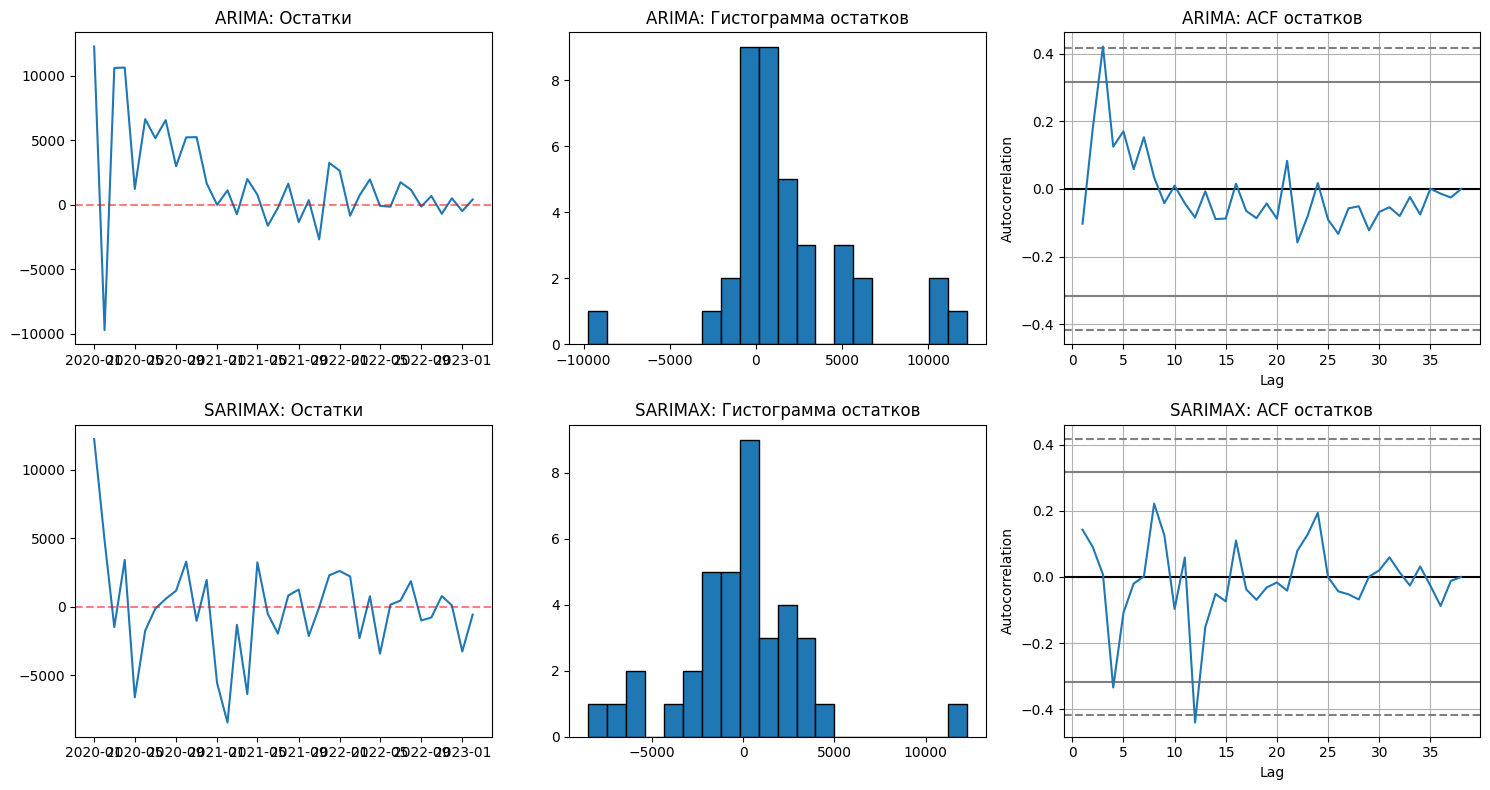

In [ ]:
# Анализ остатков
residuals_arima = fitted_arima.resid
residuals_sarima = fitted_sarima.resid

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Остатки ARIMA
axes[0, 0].plot(residuals_arima); axes[0, 0].set_title('ARIMA: Остатки')
axes[0, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[0, 1].hist(residuals_arima, bins=20, edgecolor='black'); axes[0, 1].set_title('ARIMA: Гистограмма остатков')
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(residuals_arima, ax=axes[0, 2]); axes[0, 2].set_title('ARIMA: ACF остатков')

# Остатки SARIMAX
axes[1, 0].plot(residuals_sarima); axes[1, 0].set_title('SARIMAX: Остатки')
axes[1, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1, 1].hist(residuals_sarima, bins=20, edgecolor='black'); axes[1, 1].set_title('SARIMAX: Гистограмма остатков')
autocorrelation_plot(residuals_sarima, ax=axes[1, 2]); axes[1, 2].set_title('SARIMAX: ACF остатков')

plt.tight_layout()
plt.show()

In [ ]:
if aic_arima < aic_sarima:
    print("ARIMA лучше по AIC")
else:
    print("SARIMAX лучше по AIC")

if bic_arima < bic_sarima:
    print("ARIMA лучше по BIC")
else:
    print("SARIMAX лучше по BIC")


SARIMAX лучше по AIC
SARIMAX лучше по BIC


Вывод: SARIMAX показала более точные прогнозы по всем метрикам